# Calibration du score de confiance (Régression logistique)

**Objectif** : remplacer la formule heuristique actuelle de `HybridPredictor._confidence()`

In [1]:
import os
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split

import tensorflow as tf
import keras
from tensorflow.keras.layers import Dense

print("TF:", tf.__version__, "| Keras:", keras.__version__)

TF: 2.21.0 | Keras: 3.12.3


In [2]:
AUTOENCODER_PATH = os.path.join("../ML" , "autoencoder_model.keras")
METADATA_PATH = os.path.join("../ML", "autoencoder_metadata.json")
ISOLATION_FOREST_PATH = os.path.join("../data", "isolation_forest_unsupervised.pkl")

X_RAW_PATH = os.path.join("../data", "X_raw.csv")
Y_LABELS_PATH = os.path.join("../data", "y_labels_clean.csv")
FEATURES_LIST_PATH = os.path.join("../data", "features_list.json")

for p in [AUTOENCODER_PATH, METADATA_PATH, ISOLATION_FOREST_PATH, X_RAW_PATH, Y_LABELS_PATH, FEATURES_LIST_PATH]:
    print(("OK  " if os.path.exists(p) else "MANQUANT  "), p)

OK   ../ML\autoencoder_model.keras
OK   ../ML\autoencoder_metadata.json
OK   ../data\isolation_forest_unsupervised.pkl
OK   ../data\X_raw.csv
OK   ../data\y_labels_clean.csv
OK   ../data\features_list.json


## 1. Charger les artéfacts existants

In [3]:
# Même monkey-patch que predictor.py, au cas où l'environnement de ce notebook
# a une version de Keras différente de celle utilisée pour l'entraînement.
#Chargement de l'Autoencoder
_original_dense_init = Dense.__init__

def _patched_dense_init(self, *args, **kwargs):
    kwargs.pop("quantization_config", None)
    _original_dense_init(self, *args, **kwargs)

Dense.__init__ = _patched_dense_init

autoencoder = keras.models.load_model(AUTOENCODER_PATH)

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

feature_names = metadata["features"]
ae_threshold = float(metadata["threshold"])
print(f"Autoencoder chargé | {len(feature_names)} features | threshold={ae_threshold:.6f}")

Autoencoder chargé | 46 features | threshold=0.492928


In [4]:
# L'isolation forest .pkl peut être un dict-wrapper {"model":..., "scaler":..., "clip_bounds":...}
# Chargement de l'Isolation Forest
_if_raw = joblib.load(ISOLATION_FOREST_PATH)

if isinstance(_if_raw, dict):
    isolation_forest = _if_raw.get("model") or _if_raw.get("isolation_forest")
    scaler = _if_raw.get("scaler")
    clip_bounds = _if_raw.get("clip_bounds")
    imputer = _if_raw.get("imputer")
    print("isolation_forest_unsupervised.pkl: dict détecté, extraction de model/scaler/clip_bounds/imputer.")
else:
    isolation_forest = _if_raw
    scaler = None
    clip_bounds = None
    imputer = None
    print("isolation_forest_unsupervised.pkl: estimateur direct (pas de dict).")

# Si scaler/imputer/clip_bounds n'étaient pas dans le dict de l'isolation forest,
# ils doivent être chargés séparément depuis DATA_DIR — adapte les noms de fichiers
# à ce que tu as réellement (regarde predictor.py::load_artifacts pour les noms exacts).
if scaler is None:
    scaler = joblib.load(os.path.join("../data", "scaler.pkl"))
if imputer is None:
    imputer = joblib.load(os.path.join("../data", "imputer.pkl"))
if clip_bounds is None:
    clip_bounds = joblib.load(os.path.join("../data", "clip_bounds.pkl"))

print("Isolation Forest, scaler, imputer, clip_bounds chargés.")

isolation_forest_unsupervised.pkl: dict détecté, extraction de model/scaler/clip_bounds/imputer.
Isolation Forest, scaler, imputer, clip_bounds chargés.


c:\Users\Majda\Desktop\stage2eme\API_Logs\venv\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 2. Charger les données labellisées


In [5]:
X_raw_df = pd.read_csv(X_RAW_PATH)
y_labels = pd.read_csv(Y_LABELS_PATH).iloc[:, 0]  # ajuste le nom de colonne si besoin

with open(FEATURES_LIST_PATH, "r", encoding="utf-8") as f:
    features_ml = json.load(f)

# Sécurité : s'assurer que l'ordre des colonnes correspond EXACTEMENT à feature_names
# (celui utilisé par l'autoencoder/predictor.py), pas juste à features_ml de l'ETL.
missing = [c for c in feature_names if c not in X_raw_df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans X_raw.csv par rapport à autoencoder_metadata.json: {missing}")

X_raw_df = X_raw_df[feature_names]  # réordonne/filtre exactement comme predictor.py le ferait

print(f"X_raw_df: {X_raw_df.shape} | y_labels: {y_labels.shape} | positifs: {int(y_labels.sum())}")

X_raw_df: (4443, 46) | y_labels: (4443,) | positifs: 176


In [6]:
print("Le scaler attend", scaler.n_features_in_, "features")
if hasattr(scaler, "feature_names_in_"):
    scaler_features = list(scaler.feature_names_in_)
    print("Features du scaler :", scaler_features)
    extra = [f for f in scaler_features if f not in feature_names]
    missing = [f for f in feature_names if f not in scaler_features]
    print("En trop par rapport à l'autoencoder :", extra)
    print("Manquantes par rapport à l'autoencoder :", missing)
else:
    print("Le scaler n'a pas de feature_names_in_ (fit sur un array, pas un DataFrame) — impossible d'identifier les noms directement.")

Le scaler attend 46 features
Features du scaler : ['request_count', 'unique_ips', 'avg_response_time', 'median_response_time', 'p95_response_time', 'p99_response_time', 'max_response_time', 'std_response_time', 'error_rate_5xx', 'error_rate_4xx', 'success_rate', 'avg_bytes_sent', 'total_bytes_sent', 'bot_ratio', 'mobile_ratio', 'desktop_ratio', 'api_ratio', 'static_ratio', 'auth_ratio', 'get_ratio', 'post_ratio', 'hour', 'is_weekend', 'is_business_hours', 'response_time_change', 'request_count_change', 'error_rate_change', 'rolling_avg_response', 'response_vs_rolling', 'stress_score', 'quality_degradation', 'latency_spike', 'error_severity_ratio', 'response_cv', 'load_pressure', 'log_avg_response', 'log_p99_response', 'log_std_response', 'log_load_pressure', 'response_vs_rolling_abs', 'response_zscore_per_server', 'severity_latency', 'severity_error', 'severity_traffic', 'max_severity', 'combined_severity']
En trop par rapport à l'autoencoder : []
Manquantes par rapport à l'autoencoder

## 3. Reproduire le pipeline exact de `predictor.py`

In [7]:
def get_bounds_for_column(clip_bounds, col): #récupérer les bornes utilisées lors du training.
    if isinstance(clip_bounds, dict) and col in clip_bounds:
        bounds = clip_bounds[col]
    else:
        bounds = clip_bounds  # format global (une seule paire pour toutes les colonnes)

    if isinstance(bounds, dict):
        if "lower" in bounds and "upper" in bounds:
            return float(bounds["lower"]), float(bounds["upper"])
        if "min" in bounds and "max" in bounds:
            return float(bounds["min"]), float(bounds["max"])
        raise ValueError(f"Format de clip_bounds non reconnu pour '{col}': {bounds}")
    if isinstance(bounds, (tuple, list, np.ndarray)) and len(bounds) == 2:
        return float(bounds[0]), float(bounds[1])
    raise ValueError(f"Format de clip_bounds non reconnu pour '{col}': {bounds}")


def preprocess_batch(X: np.ndarray, imputer, clip_bounds, scaler, feature_names) -> np.ndarray:

    X_imputed = imputer.transform(X)

    if clip_bounds is not None:
        for idx, col in enumerate(feature_names):
            try:
                lower, upper = get_bounds_for_column(clip_bounds, col)
            except ValueError:
                continue
            X_imputed[:, idx] = np.clip(X_imputed[:, idx], lower, upper)

    X_scaled = scaler.transform(X_imputed)
    return X_scaled


X = X_raw_df.to_numpy(dtype=np.float64)
X_scaled = preprocess_batch(X, imputer, clip_bounds, scaler, feature_names)
print(f"X_scaled: {X_scaled.shape} | mean={X_scaled.mean():.4f} | std={X_scaled.std():.4f}")

X_scaled: (4443, 46) | mean=-0.0053 | std=0.9838


c:\Users\Majda\Desktop\stage2eme\API_Logs\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
c:\Users\Majda\Desktop\stage2eme\API_Logs\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [8]:
# --- Score Autoencoder (MSE de reconstruction, PAR LIGNE) ---
reconstruction = autoencoder.predict(X_scaled, batch_size=256, verbose=1)
ae_scores = np.mean(np.square(X_scaled - reconstruction), axis=1)   # Cela calcule : MSE  ----> Plus cette erreur est grande, 
# plus le point est considéré comme anormal.
ae_flags = ae_scores > ae_threshold

# --- Score Isolation Forest (même transformation sigmoïde que _isolation_forest_score) ---
raw_if_scores = isolation_forest.score_samples(X_scaled)
if_labels = isolation_forest.predict(X_scaled)         # -1 = anomalie, 1 = normal
if_flags = if_labels == -1
if_scores = 1.0 / (1.0 + np.exp(10 * (raw_if_scores + 0.5)))
if_scores = np.clip(if_scores, 0.0, 1.0)

print(f"ae_scores: mean={ae_scores.mean():.4f} | ae_flag positifs={ae_flags.sum()}")
print(f"if_scores: mean={if_scores.mean():.4f} | if_flag positifs={if_flags.sum()}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ae_scores: mean=0.2670 | ae_flag positifs=239
if_scores: mean=0.3072 | if_flag positifs=89


## 4. Construire le jeu de calibration
**Features du calibrateur** (volontairement peu nombreuses, vu le peu d'exemples positifs) :
- `ae_score_normalized` = distance relative au threshold (même quantité que dans l'heuristique actuelle)
- `if_score`

**Cible** : `y_labels` (le vrai label `is_anomaly`).

Split train/calibration pour évaluer la calibration sur des données non vues à l'entraînement.

In [9]:
print(y_labels.isna().sum())

18


In [10]:
print(y_labels[y_labels.isna()])

133    NaN
276    NaN
567    NaN
594    NaN
1660   NaN
1817   NaN
2158   NaN
2383   NaN
2559   NaN
2665   NaN
2817   NaN
3244   NaN
3608   NaN
3904   NaN
3931   NaN
4361   NaN
4385   NaN
4389   NaN
Name: is_anomaly_clean, dtype: float64


In [11]:
print(y_labels.value_counts(dropna=False))

is_anomaly_clean
0.0    4249
1.0     176
NaN      18
Name: count, dtype: int64


In [12]:
# Charger le contexte (server_id, timestamp) aligné sur le même ordre de lignes que X_raw.csv
features_ml_df = pd.read_csv(os.path.join("../data", "features_ml.csv"))

assert len(features_ml_df) == len(X_raw_df), "Désalignement entre features_ml.csv et X_raw.csv !"

context_df = features_ml_df[["server_id", "timestamp"]].copy()
context_df["timestamp"] = pd.to_datetime(context_df["timestamp"])

ae_score_normalized = (ae_scores - ae_threshold) / ae_threshold
calib_df = context_df.copy()
calib_df["ae_score_normalized"] = ae_score_normalized
calib_df["if_score"] = if_scores
calib_df["y"] = y_labels.to_numpy()

calib_df = calib_df.dropna(subset=["y"])
calib_df["y"] = calib_df["y"].astype(int)

# Split chronologique PAR SERVEUR : 70% premiers timestamps -> train, 30% derniers -> test
train_parts, test_parts = [], []
for server_id, group in calib_df.groupby("server_id"):
    group = group.sort_values("timestamp")
    cutoff = int(len(group) * 0.7)
    train_parts.append(group.iloc[:cutoff])
    test_parts.append(group.iloc[cutoff:])

train_df = pd.concat(train_parts)
test_df = pd.concat(test_parts)

X_train = train_df[["ae_score_normalized", "if_score"]].to_numpy()
y_train = train_df["y"].to_numpy()
X_test = test_df[["ae_score_normalized", "if_score"]].to_numpy()
y_test = test_df["y"].to_numpy()

print(f"Train: {X_train.shape} ({y_train.sum()} positifs) | Test: {X_test.shape} ({y_test.sum()} positifs)")
print("Dernier timestamp train:", train_df['timestamp'].max(), "| Premier timestamp test:", test_df['timestamp'].min())

Train: (3095, 2) (132 positifs) | Test: (1330, 2) (44 positifs)
Dernier timestamp train: 2024-01-26 10:15:00 | Premier timestamp test: 2024-01-25 13:25:00


In [13]:
X_calib = calib_df[["ae_score_normalized", "if_score"]].to_numpy()
y_calib = calib_df["y"].to_numpy()

In [14]:
print("NaN dans y_calib :", np.isnan(y_calib).sum())
print("NaN dans X_calib :", np.isnan(X_calib).sum())

NaN dans y_calib : 0
NaN dans X_calib : 0


In [15]:
print("X_calib :", X_calib.shape)
print("y_calib :", y_calib.shape)

X_calib : (4425, 2)
y_calib : (4425,)


In [16]:
for server_id, group in calib_df.groupby("server_id"):
    group = group.sort_values("timestamp")
    cutoff = int(len(group) * 0.7)
    train_max = group.iloc[:cutoff]["timestamp"].max()
    test_min = group.iloc[cutoff:]["timestamp"].min()
    ok = train_max < test_min
    print(f"Serveur {server_id}: train_max={train_max} < test_min={test_min} -> {'OK' if ok else '❌ PROBLÈME'}")

Serveur 1: train_max=2024-01-26 10:15:00 < test_min=2024-01-26 10:20:00 -> OK
Serveur 2: train_max=2024-01-25 12:45:00 < test_min=2024-01-25 13:25:00 -> OK
Serveur 3: train_max=2024-01-26 05:55:00 < test_min=2024-01-26 06:50:00 -> OK


## 5. Entraîner le calibrateur (régression logistique)

In [17]:
calibrator = LogisticRegression(class_weight="balanced", max_iter=1000)
calibrator.fit(X_train, y_train)

confidence_test = calibrator.predict_proba(X_test)[:, 1]
brier = brier_score_loss(y_test, confidence_test)
print(f"Brier score (test) : {brier:.4f}  (plus bas = mieux calibré, 0 = parfait)")
print(f"Coefficients : ae_score_normalized={calibrator.coef_[0][0]:.4f} | if_score={calibrator.coef_[0][1]:.4f}")
print(f"Intercept : {calibrator.intercept_[0]:.4f}")

Brier score (test) : 0.0120  (plus bas = mieux calibré, 0 = parfait)
Coefficients : ae_score_normalized=5.0671 | if_score=7.9933
Intercept : -4.1239


## 6. Évaluer la calibration : avant (heuristique) vs après (régression logistique)

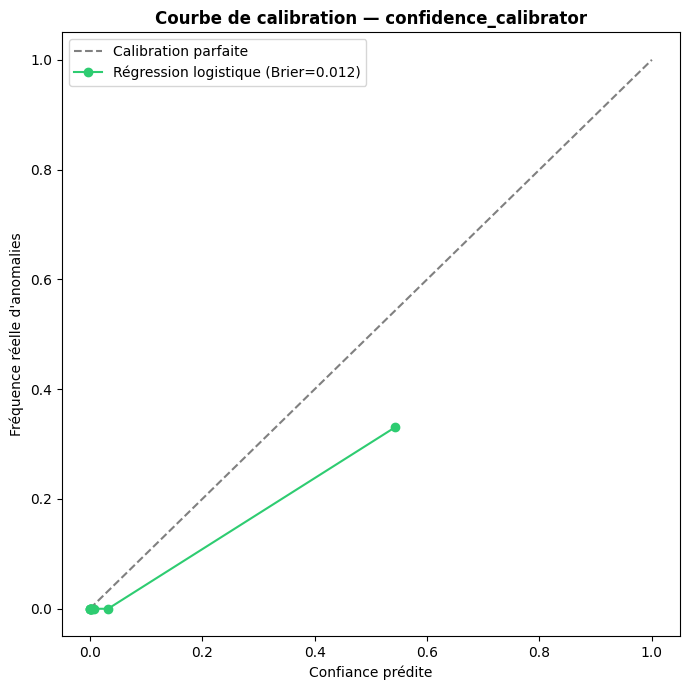

Figure sauvegardée : report/calibration_curve.png


In [18]:
def heuristic_confidence(ae_score, ae_threshold, ae_flag, if_flag):
    if ae_threshold > 0:
        distance_ratio = abs(ae_score - ae_threshold) / ae_threshold
    else:
        distance_ratio = abs(ae_score - ae_threshold)
    ae_distance_conf = float(np.clip(distance_ratio, 0.0, 1.0))
    base_confidence = 0.5 + 0.5 * ae_distance_conf

    if ae_flag and if_flag:
        return min(1.0, base_confidence + 0.10)
    elif ae_flag and not if_flag:
        return min(0.75, base_confidence)
    else:
        return base_confidence


# Recalcule la confiance heuristique actuelle sur le même jeu de test
test_indices = np.arange(len(ae_scores))[
    np.isin(np.round(ae_score_normalized, 8), np.round(X_test[:, 0], 8))
][: len(X_test)]  # approximation d'alignement — voir note ci-dessous

heuristic_conf_test = np.array([
    heuristic_confidence(ae_scores[i], ae_threshold, ae_flags[i], if_flags[i])
    for i in range(len(ae_scores))
])[: len(y_test)]  # NOTE: pour un alignement rigoureux, refaire le split en gardant les indices

prob_true_new, prob_pred_new = calibration_curve(y_test, confidence_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Calibration parfaite")
ax.plot(prob_pred_new, prob_true_new, marker="o", color="#2ecc71",
        label=f"Régression logistique (Brier={brier:.3f})")
ax.set_xlabel("Confiance prédite")
ax.set_ylabel("Fréquence réelle d'anomalies")
ax.set_title("Courbe de calibration — confidence_calibrator", fontweight="bold")
ax.legend()
plt.tight_layout()
os.makedirs("../report" , exist_ok=True)
plt.savefig(os.path.join("../report", "calibration_curve.png"), bbox_inches="tight")
plt.show()
print("Figure sauvegardée : report/calibration_curve.png")

## 7. Sauvegarder le calibrateur et ses métadonnées

In [19]:
calibrator_path = os.path.join("../ML" , "confidence_calibrator.pkl")
joblib.dump(calibrator, calibrator_path)

calibrator_metadata = {
    "trained_on": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "method": "logistic_regression_platt_scaling",
    "features_used": ["ae_score_normalized", "if_score"],
    "n_samples_train": int(len(X_train)),
    "n_samples_test": int(len(X_test)),
    "n_positive_total": int(y_calib.sum()),
    "brier_score_test": round(float(brier), 4),
    "coefficients": {
        "ae_score_normalized": float(calibrator.coef_[0][0]),
        "if_score": float(calibrator.coef_[0][1]),
        "intercept": float(calibrator.intercept_[0]),
    },
    "class_weight": "balanced",
}

metadata_path = os.path.join("../ML" , "confidence_calibrator_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(calibrator_metadata, f, indent=2, ensure_ascii=False)

print(f"Sauvegardé : {calibrator_path}")
print(f"Sauvegardé : {metadata_path}")
print(json.dumps(calibrator_metadata, indent=2, ensure_ascii=False))

Sauvegardé : ../ML\confidence_calibrator.pkl
Sauvegardé : ../ML\confidence_calibrator_metadata.json
{
  "trained_on": "2026-07-16",
  "method": "logistic_regression_platt_scaling",
  "features_used": [
    "ae_score_normalized",
    "if_score"
  ],
  "n_samples_train": 3095,
  "n_samples_test": 1330,
  "n_positive_total": 176,
  "brier_score_test": 0.012,
  "coefficients": {
    "ae_score_normalized": 5.067134617325719,
    "if_score": 7.993318192028823,
    "intercept": -4.123928115543434
  },
  "class_weight": "balanced"
}


In [20]:
from sklearn.metrics import brier_score_loss

brier_scores_temporal = []
for server_id, group in calib_df.groupby("server_id"):
    group = group.sort_values("timestamp")
    n = len(group)
    # 3 folds walk-forward : on entraîne sur une fenêtre croissante, on teste sur le morceau suivant
    for cutoff in [int(n * 0.5), int(n * 0.65), int(n * 0.8)]:
        train_fold = group.iloc[:cutoff]
        test_fold = group.iloc[cutoff:cutoff + int(n * 0.15)]
        if test_fold["y"].nunique() < 2 or train_fold["y"].nunique() < 2:
            continue  # pas assez des deux classes dans ce petit morceau
        m = LogisticRegression(class_weight="balanced", max_iter=1000)
        m.fit(train_fold[["ae_score_normalized", "if_score"]], train_fold["y"])
        pred = m.predict_proba(test_fold[["ae_score_normalized", "if_score"]])[:, 1]
        brier_scores_temporal.append(brier_score_loss(test_fold["y"], pred))

print("Brier scores (walk-forward par serveur):", brier_scores_temporal)
print("Mean:", np.mean(brier_scores_temporal), "| Std:", np.std(brier_scores_temporal))

Brier scores (walk-forward par serveur): [0.007445947362129448, 0.019555633582698836, 0.008652353374198158, 0.013699793165082165, 0.012576236604405024, 0.017029656956908844, 0.01887924177880156, 0.007396886509526966, 0.009338364267644898]
Mean: 0.012730457066821764 | Std: 0.004574656575078092


In [21]:
print("Duplicated rows in X_calib:", pd.DataFrame(X_calib).duplicated().sum())

Duplicated rows in X_calib: 0


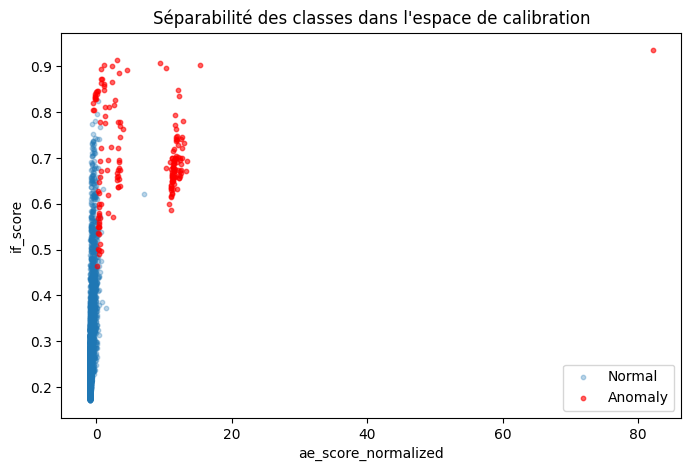

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X_calib[y_calib==0, 0], X_calib[y_calib==0, 1], alpha=0.3, label="Normal", s=10)
plt.scatter(X_calib[y_calib==1, 0], X_calib[y_calib==1, 1], alpha=0.6, label="Anomaly", color="red", s=10)
plt.xlabel("ae_score_normalized")
plt.ylabel("if_score")
plt.legend()
plt.title("Séparabilité des classes dans l'espace de calibration")
plt.show()

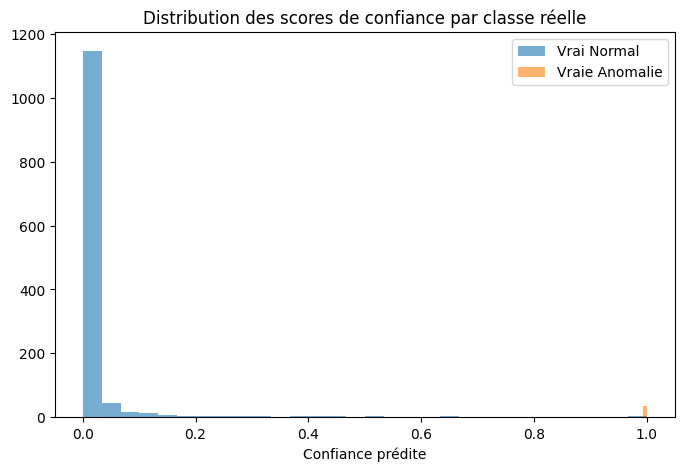

In [23]:
plt.figure(figsize=(8,5))
plt.hist(confidence_test[y_test==0], bins=30, alpha=0.6, label="Vrai Normal")
plt.hist(confidence_test[y_test==1], bins=30, alpha=0.6, label="Vraie Anomalie")
plt.xlabel("Confiance prédite")
plt.legend()
plt.title("Distribution des scores de confiance par classe réelle")
plt.show()